# AES-T500 data set

## Import libraries

In [14]:
# %reset
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from pyts.image import GramianAngularField


## Set Parameters

In [15]:
num_epochs = 100
sample_numbers = 10000
data_name ='T500'
im_size_gram=128


## Paths

In [ ]:
base_path=f"\AIoT_project\data_sets\IEEE_dataPort\AES-{data_name}_power_Temp25C\AES-{data_name}_power_Temp25C"
trj_disabled= f"\AES-{data_name}+TrojanDisabled_1\AES-{data_name}+TrojanDisabled_1"
trj_enabled= f"\AES-{data_name}+TrojanTriggered_1\AES-{data_name}+TrojanTriggered_1"

## load and prepare data

In [17]:
data_folder = Path(base_path + trj_disabled)
# Initialize a list to hold all arrays
labeled_arrays = []
# Loop through file indices
for i in range(sample_numbers):  # 500 because range is exclusive of the upper bound
    file_path = data_folder / f"Sample_{i}.csv"
    
    # Read the file
    data = pd.read_csv(file_path, header=None)
    
    # Convert the column to a NumPy array
    array = data[0].to_numpy()

    # Create a labeled array (features + label)
    labeled_array = np.append(array, 0)  # Appending label '0' for disabled

    # Append the labeled array to the list
    labeled_arrays.append(labeled_array)

# Convert the list of labeled arrays into a 2D NumPy array (matrix)
trj_data_disb = np.array(labeled_arrays)


data_folder = Path(base_path + trj_enabled)
# Initialize a list to hold all arrays
labeled_arrays = []
# Loop through file indices
for i in range(sample_numbers):  # 500 because range is exclusive of the upper bound
    file_path = data_folder / f"Sample_{i}.csv"
    
    # Read the file
    data = pd.read_csv(file_path, header=None)
    
    # Convert the column to a NumPy array
    array = data[0].to_numpy()

    # Create a labeled array (features + label)
    labeled_array = np.append(array, 1)  # Appending label '1' for disabled

    # Append the labeled array to the list
    labeled_arrays.append(labeled_array)


# Convert the list of arrays into a 2D NumPy array (matrix)
trj_data_trig = np.array(labeled_arrays)


# Concatenate trj_data_disb and trj_data_trig row-wise
trj_data = np.concatenate((trj_data_disb, trj_data_trig), axis=0)
# Shuffle the combined dataset
np.random.shuffle(trj_data)


# Splitting the data
X_train, X_val, y_train, y_val = train_test_split(trj_data[:, :-1], trj_data[:, -1], test_size=0.2)  # 20% for validation
tf_gs=GramianAngularField(image_size=im_size_gram,method='summation')
X_train=tf_gs.fit_transform(X_train)
X_val=tf_gs.fit_transform(X_val)


X_train = X_train.reshape(-1, 1, im_size_gram, im_size_gram)
X_val = X_val.reshape(-1, 1, im_size_gram, im_size_gram)

# Calculate mean and standard deviation for normalization
mean = X_train.mean()
std = X_train.std()

# Normalize the datasets
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std

## Convert to PyTorch tensors

In [18]:

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

# Create DataLoader for training and validation sets
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=32)

## Define the CNN model


In [19]:

# Define the CNN model
class CNN_gafs(nn.Module):
    def __init__(self):
        super(CNN_gafs, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2)
        self.fc1 = nn.Linear(65536,1000)  
        self.fc2 = nn.Linear(1000, 2)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)  # Flatten
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x
model=CNN_gafs()

# model = nn.Sequential(
#           nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=2),
#           nn.ReLU(),
#           nn.MaxPool2d(kernel_size=2, stride=2),
#           nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=2),
#           nn.ReLU(),
#           nn.MaxPool2d(kernel_size=2, stride=2),
#           nn.Flatten(),
#           nn.Linear(69696,100),  # Adjust the size
#           nn.ReLU(),
#           nn.Linear(100, 2)
#         )


## Initialize model, loss function, and optimizer

In [20]:
# Ensure the model is on GPU
# Check if more than one GPU is available and wrap the model using nn.DataParallel
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


Using 4 GPUs!


## Training loop and validation

In [ ]:
train_losses, val_losses, val_accuracies = [], [], []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    accuracy = 100 * correct / total
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}, Accuracy: {accuracy:.2f}%')


## Plotting


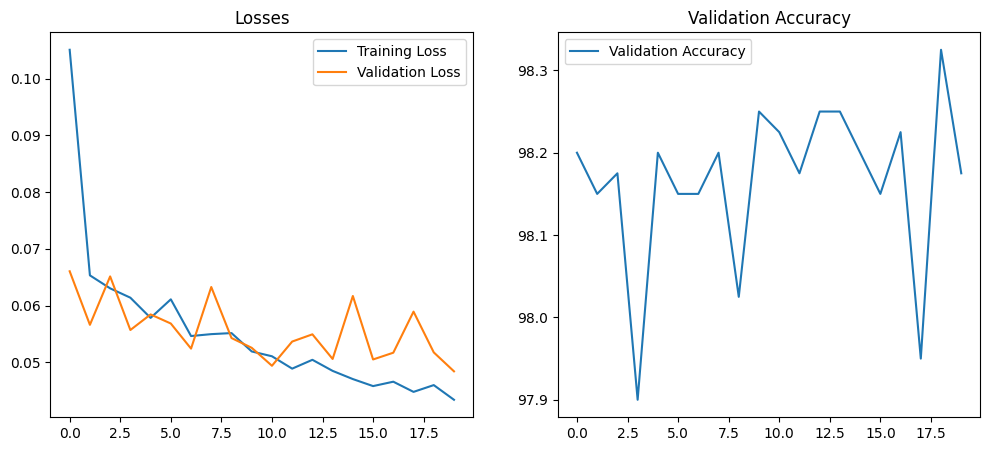

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("Losses")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title("Validation Accuracy")
plt.legend()
plt.show()